# SHAP Analysis Notebook
FirstBank Cross-Sell Propensity Model — BAN6800 Module 4

Global and local explainability analysis for the champion model (Logistic Regression), registered in MLflow as `firstbank-cross-sell-propensity-model`.

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/processed")
ASSET_DIR = Path("../../assets")

model = joblib.load(ASSET_DIR / "logreg_model.joblib")
preprocessor = joblib.load(DATA_DIR / "preprocessor.joblib")
feature_names = joblib.load(DATA_DIR / "feature_names.joblib")
print(f"Champion model: {type(model).__name__}")
print(f"Features: {len(feature_names)}")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Champion model: LogisticRegression
Features: 31


## Load test data and transform

In [2]:
X_train_raw = pd.read_csv(DATA_DIR / "X_train.csv")
X_test_raw = pd.read_csv(DATA_DIR / "X_test.csv")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()

X_train = preprocessor.transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_test_df.head()

,age,account_balance,recency_days,frequency,monetary_total,monetary_avg,share_ATM Withdrawal,share_Airtime/Data,share_Bill Payment,share_Loan Repayment,...,location_Imo,location_Kaduna,location_Kano,location_Kwara,location_Lagos,location_Ogun,location_Oyo,location_Plateau,location_Rivers,location_Unknown
0,2.338993,0.020404,-1.025407,0.005437,-0.338795,-0.334338,-0.408810,-0.581642,0.580864,1.754495,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-1.391156,-0.187663,-0.982988,1.248128,1.162978,0.511150,-0.606445,-0.581642,-0.154286,0.415289,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.846934,3.334312,-0.830279,-2.065715,-0.654162,0.061079,-0.606445,4.393086,-0.581063,-0.593303,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.515365,-0.573451,0.094457,-1.651485,-0.521496,0.031848,2.909584,-0.581642,-0.581063,-0.593303,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.064880,-0.292982,-0.440024,0.005437,0.139355,0.142071,-0.606445,-0.581642,-0.198584,-0.042781,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Global explainability: SHAP LinearExplainer

Background dataset has 4800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4800 when initializing the masker.


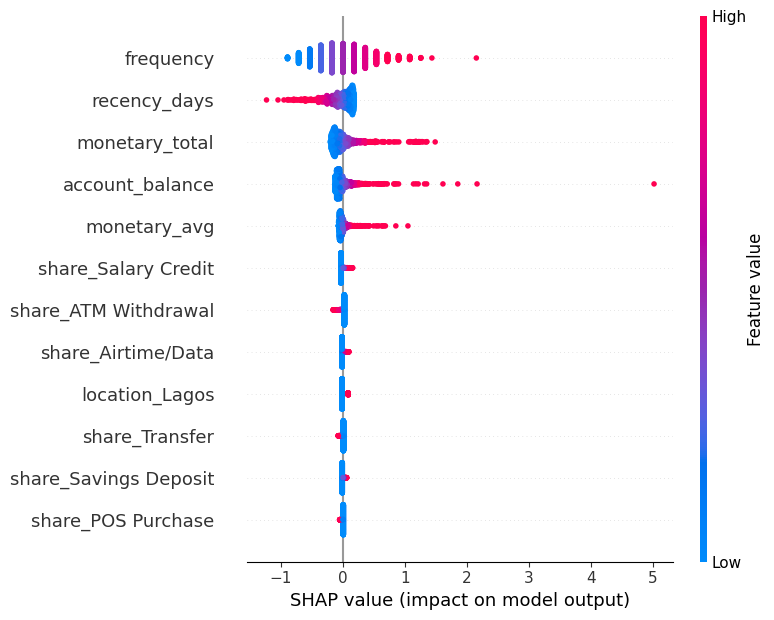

In [3]:
explainer = shap.LinearExplainer(model, X_train_df)
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df, max_display=12)

**Interpretation:** `frequency`, `recency_days`, `monetary_total`, and `account_balance` dominate the model's decisions. High transaction frequency and monetary engagement push predictions toward conversion; high recency (long time since last transaction) pushes toward non-conversion. This matches the business logic used to define the propensity target and gives relationship managers a clear, actionable story: engagement drives propensity, not demographics.

## Local explainability: individual prediction (SHAP waterfall)

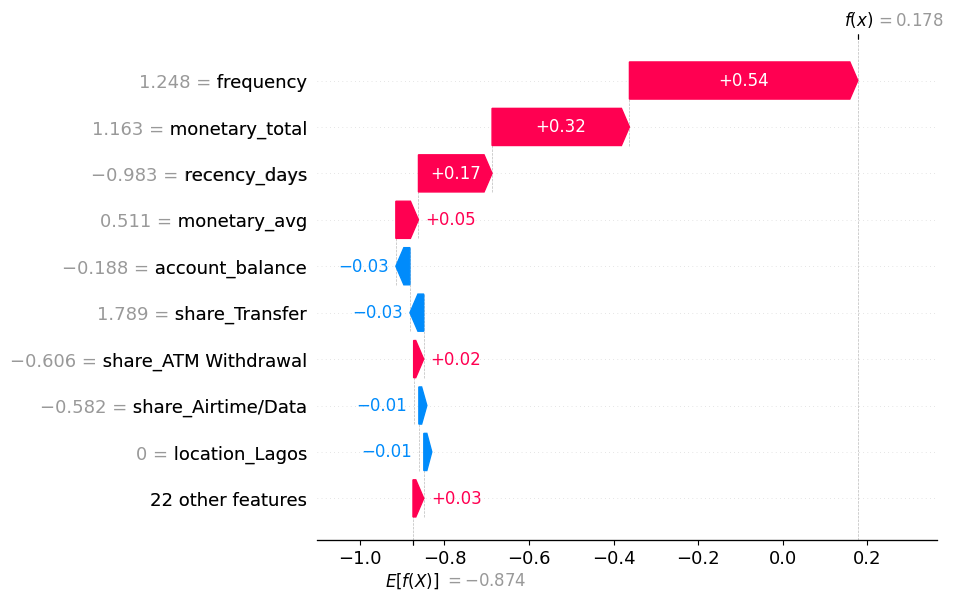

In [4]:
y_proba = model.predict_proba(X_test)[:, 1]
converter_idx = np.where((y_test.values == 1) & (y_proba > 0.5))[0][0]

shap.plots.waterfall(shap_values[converter_idx], max_display=10)

## Mean |SHAP| feature ranking (exported for the Model Validation Report)

In [5]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance_df = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
importance_df.sort_values("mean_abs_shap", ascending=False).head(10)

,feature,mean_abs_shap
3,frequency,0.349452
2,recency_days,0.153982
4,monetary_total,0.146479
1,account_balance,0.111455
5,monetary_avg,0.050267
12,share_Salary Credit,0.031846
6,share_ATM Withdrawal,0.027478
7,share_Airtime/Data,0.016436
25,location_Lagos,0.016295
14,share_Transfer,0.012118
